# 06 — SwinIR

**Goal:** Train and evaluate SwinIR (Swin Transformer Image Restoration).

In [4]:
import warnings
warnings.filterwarnings('ignore')

import os, sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import rasterio
from pathlib import Path
from skimage.transform import resize as sk_resize
from tqdm import tqdm

sys.path.insert(0, "..")
from metrics import psnr, ssim, enl, evaluate_arrays, print_results

print(f"TensorFlow : {tf.__version__}")
print(f"GPUs       : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.19.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Configuration

In [5]:
BASE_DIR = '/kaggle/input/datasets/vinhnh96/stac-dataset'

BASE_WORK_DIR = '/kaggle/working'

DATASET_DIR  = Path(BASE_DIR + "/stac_dataset")

CKPT_DIR     = Path(BASE_WORK_DIR + "/checkpoints/swinir")
LOG_DIR      = Path(BASE_WORK_DIR + "/logs/swinir")
REPORTS_DIR  = Path(BASE_WORK_DIR + "/reports")

for d in [CKPT_DIR, LOG_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Native patch sizes on disk
NATIVE_LR = 128
NATIVE_HR = 512
SCALE     = 4

# Crop size fed to the model (64x64 LR -> 256x256 HR)
# Using crops instead of full patches reduces compute ~4x per forward pass.
# Random crops are used during training; center crops for val/test.
LR_SIZE = 64
HR_SIZE = LR_SIZE * SCALE   # 256

# Lightweight SwinIR architecture
# Reduced from the full model to fit within practical training time.
EMBED_DIM   = 32
NUM_HEADS   = 4      # head_dim = 32 / 4 = 8
WINDOW_SIZE = 8      # 64 / 8 = 8 windows per dim
STL_DEPTH   = 2      # Swin Transformer Layers per RSTB
NUM_RSTB    = 2      # number of Residual Swin Transformer Blocks
MLP_RATIO   = 2.0

BATCH_SIZE = 16      # larger batch fits because inputs are smaller
EPOCHS     = 100
LR         = 2e-4
SEED       = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"Model input  : {LR_SIZE} x {LR_SIZE} LR -> {HR_SIZE} x {HR_SIZE} HR")
print(f"EMBED_DIM={EMBED_DIM}, NUM_HEADS={NUM_HEADS}, WINDOW_SIZE={WINDOW_SIZE}")
print(f"STL_DEPTH={STL_DEPTH}, NUM_RSTB={NUM_RSTB} -> {STL_DEPTH * NUM_RSTB} transformer layers total")

Model input  : 64 x 64 LR -> 256 x 256 HR
EMBED_DIM=32, NUM_HEADS=4, WINDOW_SIZE=8
STL_DEPTH=2, NUM_RSTB=2 -> 4 transformer layers total


## 1. Dataset split (identical to SRCNN — seed=42)

In [6]:
all_hr = sorted(DATASET_DIR.glob("*_HR.tif"))
all_lr = sorted(DATASET_DIR.glob("*_LR.tif"))
assert len(all_hr) == len(all_lr)

n_total = len(all_hr)
indices = np.arange(n_total)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

n_test  = int(n_total * 0.10)
n_val   = int(n_total * 0.10)
n_train = n_total - n_val - n_test

train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

print(f"Total  : {n_total:,}")
print(f"Train  : {len(train_idx):,}")
print(f"Val    : {len(val_idx):,}")
print(f"Test   : {len(test_idx):,}")

Total  : 6,047
Train  : 4,839
Val    : 604
Test   : 604


## 2. tf.data pipeline

Unlike SRCNN, SwinIR takes the raw LR (128x128) directly — no bicubic pre-upsampling.
The model handles upsampling internally via PixelShuffle.

In [7]:
def _load_and_normalise(hr_path, lr_path):
    """Read both patches from disk and normalise to [0, 1] using HR max."""
    with rasterio.open(hr_path) as src:
        hr = src.read(1).astype(np.float32)
    with rasterio.open(lr_path) as src:
        lr = src.read(1).astype(np.float32)
    max_val = hr.max()
    if max_val > 0:
        hr = hr / max_val
        lr = lr / max_val
    return hr, lr


def load_pair_train(hr_path_str, lr_path_str):
    """Load and randomly crop to LR_SIZE x LR_SIZE (LR) / HR_SIZE x HR_SIZE (HR)."""
    hr, lr = _load_and_normalise(
        hr_path_str.numpy().decode(), lr_path_str.numpy().decode()
    )
    # Random crop origin on LR grid; corresponding HR crop scaled by SCALE
    top  = np.random.randint(0, NATIVE_LR - LR_SIZE + 1)
    left = np.random.randint(0, NATIVE_LR - LR_SIZE + 1)
    lr_crop = np.clip(lr[top:top+LR_SIZE, left:left+LR_SIZE], 0, 1)
    hr_crop = hr[top*SCALE:(top+LR_SIZE)*SCALE, left*SCALE:(left+LR_SIZE)*SCALE]
    return lr_crop[..., np.newaxis], hr_crop[..., np.newaxis]


def load_pair_eval(hr_path_str, lr_path_str):
    """Load and center-crop to LR_SIZE x LR_SIZE for consistent val/test evaluation."""
    hr, lr = _load_and_normalise(
        hr_path_str.numpy().decode(), lr_path_str.numpy().decode()
    )
    top  = (NATIVE_LR - LR_SIZE) // 2
    left = (NATIVE_LR - LR_SIZE) // 2
    lr_crop = np.clip(lr[top:top+LR_SIZE, left:left+LR_SIZE], 0, 1)
    hr_crop = hr[top*SCALE:(top+LR_SIZE)*SCALE, left*SCALE:(left+LR_SIZE)*SCALE]
    return lr_crop[..., np.newaxis], hr_crop[..., np.newaxis]


def make_dataset(idx_array, shuffle=False, train=False):
    hr_paths = [str(all_hr[i]) for i in idx_array]
    lr_paths = [str(all_lr[i]) for i in idx_array]
    load_fn  = load_pair_train if train else load_pair_eval

    ds = tf.data.Dataset.from_tensor_slices((hr_paths, lr_paths))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(idx_array), seed=SEED)

    ds = ds.map(
        lambda hr, lr: tf.py_function(load_fn, [hr, lr], [tf.float32, tf.float32]),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    ds = ds.map(lambda lr, hr: (
        tf.ensure_shape(lr, [LR_SIZE, LR_SIZE, 1]),
        tf.ensure_shape(hr, [HR_SIZE, HR_SIZE, 1]),
    ))
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_idx, shuffle=True, train=True)
val_ds   = make_dataset(val_idx,   train=False)
test_ds  = make_dataset(test_idx,  train=False)

for lr_b, hr_b in train_ds.take(1):
    print(f"LR batch : {lr_b.shape}  range=[{lr_b.numpy().min():.3f}, {lr_b.numpy().max():.3f}]")
    print(f"HR batch : {hr_b.shape}  range=[{hr_b.numpy().min():.3f}, {hr_b.numpy().max():.3f}]")

I0000 00:00:1775928442.186006      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775928442.191748      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


LR batch : (16, 64, 64, 1)  range=[0.003, 0.642]
HR batch : (16, 256, 256, 1)  range=[0.000, 1.000]


## 3. SwinIR model

### Architecture overview

```
LR (128x128x1)
    |
[Shallow feature extraction]  Conv2D 3x3 -> (128x128xC)
    |
[Deep feature extraction]     N x RSTB -> (128x128xC)
    |  each RSTB contains:
    |    D x SwinTransformerBlock (alternating W-MSA / SW-MSA)
    |    + LayerNorm + residual Conv2D
    |
[Reconstruction]              Conv2D -> PixelShuffle 4x -> Conv2D
    |
SR output (512x512x1)
```

### Window attention
- W-MSA: attention within 8x8 windows (64 tokens each)
- SW-MSA: windows shifted by 4 pixels to enable cross-window information flow
- Relative position bias: trainable bias added to attention logits

In [8]:
# ---------------------------------------------------------------------------
# Window utility functions
# ---------------------------------------------------------------------------

def window_partition(x, window_size):
    """Partition (B, H, W, C) into (num_windows*B, ws, ws, C)."""
    B = tf.shape(x)[0]
    H, W, C = x.shape[1], x.shape[2], x.shape[3]
    x = tf.reshape(x, [B, H // window_size, window_size,
                           W // window_size, window_size, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
    return tf.reshape(x, [-1, window_size, window_size, C])


def window_reverse(windows, window_size, H, W):
    """Reverse partition from (num_windows*B, ws, ws, C) back to (B, H, W, C)."""
    C = windows.shape[-1]
    num_win = (H // window_size) * (W // window_size)
    B = tf.shape(windows)[0] // num_win
    x = tf.reshape(windows, [B, H // window_size, W // window_size,
                                 window_size, window_size, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
    return tf.reshape(x, [B, H, W, C])


def compute_attn_mask(H, W, window_size, shift_size):
    """Precompute SW-MSA attention mask as a numpy-derived TF constant."""
    img_mask = np.zeros((1, H, W, 1), dtype=np.float32)
    h_slices = (slice(0, -window_size),
                slice(-window_size, -shift_size),
                slice(-shift_size, None))
    w_slices = (slice(0, -window_size),
                slice(-window_size, -shift_size),
                slice(-shift_size, None))
    cnt = 0
    for h in h_slices:
        for w in w_slices:
            img_mask[:, h, w, :] = cnt
            cnt += 1

    mask_win = window_partition(tf.constant(img_mask), window_size)
    mask_win = tf.reshape(mask_win, [-1, window_size * window_size])
    attn_mask = tf.expand_dims(mask_win, 1) - tf.expand_dims(mask_win, 2)
    attn_mask = tf.where(attn_mask != 0,
                         tf.fill(tf.shape(attn_mask), -100.0),
                         tf.zeros_like(attn_mask))
    return attn_mask  # (num_windows, ws*ws, ws*ws)

In [9]:
# ---------------------------------------------------------------------------
# Relative Position Bias
# ---------------------------------------------------------------------------

class RelativePositionBias(tf.keras.layers.Layer):
    """Trainable relative position bias added to attention logits."""

    def __init__(self, window_size, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.window_size = window_size
        self.num_heads = num_heads

        ws = window_size
        coords_h = np.arange(ws)
        coords_w = np.arange(ws)
        coords = np.stack(np.meshgrid(coords_h, coords_w, indexing="ij"))  # (2, ws, ws)
        coords_flat = coords.reshape(2, -1)  # (2, ws^2)
        rel = coords_flat[:, :, None] - coords_flat[:, None, :]  # (2, ws^2, ws^2)
        rel = rel.transpose(1, 2, 0)   # (ws^2, ws^2, 2)
        rel[:, :, 0] += ws - 1
        rel[:, :, 1] += ws - 1
        rel[:, :, 0] *= 2 * ws - 1
        # Store as numpy — converting to tf.constant in __init__ creates a tensor
        # in a temporary scratch graph that is out of scope when call() runs.
        self._rel_idx_np = rel.sum(-1).flatten().astype(np.int32)

    def build(self, input_shape=None):
        ws = self.window_size
        self.bias_table = self.add_weight(
            name="bias_table",
            shape=((2 * ws - 1) ** 2, self.num_heads),
            initializer="truncated_normal",
            trainable=True,
        )
        self.built = True

    def call(self, inputs=None):
        ws2 = self.window_size ** 2
        # tf.gather accepts numpy arrays directly — tensor is created in the
        # correct graph context at call time, not at layer construction time.
        bias = tf.gather(self.bias_table, self._rel_idx_np)   # (ws^4, num_heads)
        bias = tf.reshape(bias, [ws2, ws2, self.num_heads])
        bias = tf.transpose(bias, [2, 0, 1])               # (num_heads, ws^2, ws^2)
        return tf.expand_dims(bias, 0)                     # (1, num_heads, ws^2, ws^2)

In [10]:
# ---------------------------------------------------------------------------
# Window Multi-Head Self-Attention
# ---------------------------------------------------------------------------

class WindowAttention(tf.keras.layers.Layer):
    def __init__(self, dim, window_size, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

    def build(self, input_shape=None):
        self.qkv  = tf.keras.layers.Dense(self.dim * 3, use_bias=True, name="qkv")
        self.proj = tf.keras.layers.Dense(self.dim, name="proj")
        self.rpb  = RelativePositionBias(self.window_size, self.num_heads, name="rpb")
        self.rpb.build(None)
        self.built = True

    def call(self, x, mask=None, training=None):
        # x: (num_windows*B, ws*ws, C)
        B_ = tf.shape(x)[0]
        N  = self.window_size ** 2

        qkv = self.qkv(x)  # (B_, N, 3*dim)
        qkv = tf.reshape(qkv, [B_, N, 3, self.num_heads, self.head_dim])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])  # (3, B_, heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = tf.matmul(q * self.scale, k, transpose_b=True)  # (B_, heads, N, N)
        attn = attn + self.rpb()                                 # broadcast over B_

        if mask is not None:
            nW = mask.shape[0]
            attn = tf.reshape(attn, [B_ // nW, nW, self.num_heads, N, N])
            attn = attn + tf.cast(
                tf.reshape(mask, [1, nW, 1, N, N]), tf.float32
            )
            attn = tf.reshape(attn, [B_, self.num_heads, N, N])

        attn = tf.nn.softmax(attn, axis=-1)

        out = tf.matmul(attn, v)                       # (B_, heads, N, head_dim)
        out = tf.transpose(out, [0, 2, 1, 3])          # (B_, N, heads, head_dim)
        out = tf.reshape(out, [B_, N, self.dim])
        return self.proj(out)

In [11]:
# ---------------------------------------------------------------------------
# Swin Transformer Layer (one STL = norm + attention + norm + MLP + residuals)
# ---------------------------------------------------------------------------

class SwinTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, dim, num_heads, window_size, shift_size,
                 mlp_ratio, input_resolution, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.shift_size = shift_size
        self.H, self.W = input_resolution
        self.window_size = window_size

        self._attn_mask = (
            compute_attn_mask(self.H, self.W, window_size, shift_size)
            if shift_size > 0 else None
        )

        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-5, name="norm1")
        self.attn  = WindowAttention(dim, window_size, num_heads, name="attn")
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-5, name="norm2")
        mlp_hidden = int(dim * mlp_ratio)
        self.mlp_fc1 = tf.keras.layers.Dense(mlp_hidden, activation="gelu", name="mlp1")
        self.mlp_fc2 = tf.keras.layers.Dense(dim, name="mlp2")

    def call(self, x, training=None):
        # x: (B, H*W, C)
        B  = tf.shape(x)[0]
        H, W, C = self.H, self.W, self.dim

        shortcut = x
        x = self.norm1(x)
        x = tf.reshape(x, [B, H, W, C])

        if self.shift_size > 0:
            x = tf.roll(x, shift=[-self.shift_size, -self.shift_size], axis=[1, 2])

        # Partition -> attention -> reverse
        x_win = window_partition(x, self.window_size)           # (nW*B, ws, ws, C)
        x_win = tf.reshape(x_win, [-1, self.window_size ** 2, C])
        x_win = self.attn(x_win, mask=self._attn_mask, training=training)
        x_win = tf.reshape(x_win, [-1, self.window_size, self.window_size, C])
        x = window_reverse(x_win, self.window_size, H, W)       # (B, H, W, C)

        if self.shift_size > 0:
            x = tf.roll(x, shift=[self.shift_size, self.shift_size], axis=[1, 2])

        x = tf.reshape(x, [B, H * W, C])
        x = shortcut + x
        x = x + self.mlp_fc2(self.mlp_fc1(self.norm2(x), training=training), training=training)
        return x

In [12]:
# ---------------------------------------------------------------------------
# Residual Swin Transformer Block (RSTB)
# ---------------------------------------------------------------------------

class RSTB(tf.keras.layers.Layer):
    """Stack of SwinTransformerBlocks with alternating W-MSA/SW-MSA + residual Conv.

    Blocks are stored via setattr (not a plain Python list) to guarantee Keras
    tracks them as sub-layers and includes their weights in trainable_variables.
    """

    def __init__(self, dim, depth, num_heads, window_size,
                 mlp_ratio, input_resolution, **kwargs):
        super().__init__(**kwargs)
        self.H, self.W = input_resolution
        self.dim   = dim
        self._depth = depth

        for i in range(depth):
            setattr(self, f"stb_{i}", SwinTransformerBlock(
                dim=dim,
                num_heads=num_heads,
                window_size=window_size,
                shift_size=0 if (i % 2 == 0) else window_size // 2,
                mlp_ratio=mlp_ratio,
                input_resolution=input_resolution,
                name=f"stb_{i}",
            ))
        self.norm     = tf.keras.layers.LayerNormalization(epsilon=1e-5, name="norm")
        self.res_conv = tf.keras.layers.Conv2D(dim, 3, padding="same", name="res_conv")

    def call(self, x, training=None):
        B = tf.shape(x)[0]
        shortcut = x

        for i in range(self._depth):
            x = getattr(self, f"stb_{i}")(x, training=training)
        x = self.norm(x)

        x = tf.reshape(x, [B, self.H, self.W, self.dim])
        x = self.res_conv(x, training=training)
        x = tf.reshape(x, [B, self.H * self.W, self.dim])

        return shortcut + x

In [13]:
# ---------------------------------------------------------------------------
# Full SwinIR model
# ---------------------------------------------------------------------------

class SwinIR(tf.keras.Model):
    """Full SwinIR model.

    RSTB blocks are stored via setattr (not a plain Python list) to guarantee
    Keras tracks them as sub-layers and includes all their weights in
    trainable_variables. Using a plain list can silently exclude transformer
    block weights from gradient updates, causing poor/unstable training.
    """

    def __init__(self, lr_size, embed_dim, num_heads, window_size,
                 depth, num_rstb, mlp_ratio, upscale, **kwargs):
        super().__init__(name="SwinIR", **kwargs)
        self.lr_size   = lr_size
        self.embed_dim = embed_dim
        self.upscale   = upscale
        self._num_rstb = num_rstb
        res = (lr_size, lr_size)

        self.shallow_feat    = tf.keras.layers.Conv2D(embed_dim, 3, padding="same", name="shallow")
        for i in range(num_rstb):
            setattr(self, f"rstb_{i}",
                    RSTB(embed_dim, depth, num_heads, window_size, mlp_ratio, res, name=f"rstb_{i}"))
        self.norm            = tf.keras.layers.LayerNormalization(epsilon=1e-5, name="norm")
        self.conv_after_body = tf.keras.layers.Conv2D(embed_dim, 3, padding="same", name="conv_after_body")
        self.upsample_conv   = tf.keras.layers.Conv2D(embed_dim * upscale ** 2, 3, padding="same", name="upsample")
        self.conv_last       = tf.keras.layers.Conv2D(1, 3, padding="same", activation="sigmoid", name="conv_last")

    def call(self, x, training=None):
        B = tf.shape(x)[0]
        H = W = self.lr_size
        C = self.embed_dim

        feat = self.shallow_feat(x, training=training)       # (B, H, W, C)
        seq  = tf.reshape(feat, [B, H * W, C])               # (B, H*W, C)

        for i in range(self._num_rstb):
            seq = getattr(self, f"rstb_{i}")(seq, training=training)
        seq = self.norm(seq)

        deep = tf.reshape(seq, [B, H, W, C])
        deep = self.conv_after_body(deep, training=training)
        deep = deep + feat                                   # long skip connection

        up = self.upsample_conv(deep, training=training)     # (B, H, W, C*16)
        up = tf.nn.depth_to_space(up, self.upscale)          # (B, 4H, 4W, C)
        return self.conv_last(up, training=training)          # (B, 4H, 4W, 1)


model = SwinIR(
    lr_size=LR_SIZE, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
    window_size=WINDOW_SIZE, depth=STL_DEPTH, num_rstb=NUM_RSTB,
    mlp_ratio=MLP_RATIO, upscale=SCALE,
)

# Run a forward pass with a dummy batch — this builds all nested layers
# properly so model.summary() can report accurate layer counts and shapes.
# The original tf.constant scratch-graph error is now resolved (RelativePositionBias
# stores its index as numpy, not tf.constant).
_ = model(tf.zeros([2, LR_SIZE, LR_SIZE, 1]), training=False)
model.summary()

total_params = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f"\nTrainable parameters : {total_params:,}")

I0000 00:00:1775928449.006460      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


Model: "SwinIR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ shallow (Conv2D)                │ (2, 64, 64, 32)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rstb_0 (RSTB)                   │ ?                      │        28,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rstb_1 (RSTB)                   │ ?                      │        28,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm (LayerNormalization)       │ (2, 4096, 32)          │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_after_body (Conv2D)        │ (2, 64, 64, 32)        │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ upsample (Conv2D)               │ (2, 64, 64, 512)       │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_last (Conv2D)              │ (2, 256, 256, 1)       │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,289 (837.07 KB)

 Trainable params: 214,289 (837.07 KB)

 Non-trainable params: 0 (0.00 B)


Trainable parameters : 214,289


## 4. Bicubic baseline (same test set — for comparison table)

In [14]:
y_true_bic, y_pred_bic = [], []

for idx in tqdm(test_idx, desc="Bicubic baseline"):
    with rasterio.open(all_hr[idx]) as src:
        hr_full = src.read(1).astype(np.float32)
    with rasterio.open(all_lr[idx]) as src:
        lr_full = src.read(1).astype(np.float32)

    max_val = hr_full.max()
    if max_val > 0:
        hr_full = hr_full / max_val
        lr_full = lr_full / max_val

    # Center crop — matches the eval pipeline used for val/test
    top  = (NATIVE_LR - LR_SIZE) // 2
    left = (NATIVE_LR - LR_SIZE) // 2
    lr_crop = np.clip(lr_full[top:top+LR_SIZE, left:left+LR_SIZE], 0, 1)
    hr_crop = hr_full[top*SCALE:(top+LR_SIZE)*SCALE, left*SCALE:(left+LR_SIZE)*SCALE]

    lr_up = sk_resize(lr_crop, (HR_SIZE, HR_SIZE), order=3,
                      anti_aliasing=True, preserve_range=True).astype(np.float32)
    y_true_bic.append(hr_crop)
    y_pred_bic.append(np.clip(lr_up, 0.0, 1.0))

bicubic_results = evaluate_arrays(y_true_bic, y_pred_bic)
print_results(bicubic_results, "Bicubic baseline (64x64 LR center crop, test set)")

Bicubic baseline: 100%|██████████| 604/604 [00:38<00:00, 15.52it/s]



Bicubic baseline (64x64 LR center crop, test set)
------------------------------------
  PSNR      : 29.8260 dB
  SSIM      : 0.6090
  ENL pred  : 40.8577
  ENL true  : 10.5417
------------------------------------


## 5. Training

In [15]:
model.compile(
    # clipnorm=1.0 clips the global gradient norm to 1.0 before each update.
    # This prevents the attention logits from causing gradient spikes, which
    # was the root cause of the unstable loss curve (spikes up and down).
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0),
    loss=tf.keras.losses.MeanAbsoluteError(),
    metrics=[tf.keras.metrics.MeanSquaredError(name="mse")],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CKPT_DIR / "best.weights.h5"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.TensorBoard(log_dir=str(LOG_DIR), histogram_freq=0),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/100


I0000 00:00:1775928505.193483     132 service.cc:152] XLA service 0x795e4c00f970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775928505.193515     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775928505.193522     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-04-11 17:28:32.110614: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 17:28:32.250059: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1775928521.163073     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for th

302/303 ━━━━━━━━━━━━━━━━━━━━ 0s 878ms/step - loss: 0.0734 - mse: 0.0135

2026-04-11 17:33:10.855792: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 17:33:11.066077: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 17:33:11.339847: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 17:33:11.478086: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 917ms/step - loss: 0.0734 - mse: 0.0134
Epoch 1: val_loss improved from inf to 0.03980, saving model to /kaggle/working/checkpoints/swinir/best.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 344s 1s/step - loss: 0.0733 - mse: 0.0134 - val_loss: 0.0398 - val_mse: 0.0037 - learning_rate: 2.0000e-04
Epoch 2/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.0407 - mse: 0.0039
Epoch 2: val_loss improved from 0.03980 to 0.03682, saving model to /kaggle/working/checkpoints/swinir/best.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 66s 218ms/step - loss: 0.0407 - mse: 0.0039 - val_loss: 0.0368 - val_mse: 0.0033 - learning_rate: 2.0000e-04
Epoch 3/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.0377 - mse: 0.0033
Epoch 3: val_loss improved from 0.03682 to 0.03410, saving model to /kaggle/working/checkpoints/swinir/best.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 62s 206ms/step - loss: 0.0377 - mse: 0.0033 - val_loss: 0.0341 - val_mse: 0.0028 - learning_rate: 2.0000

## 6. Training curves

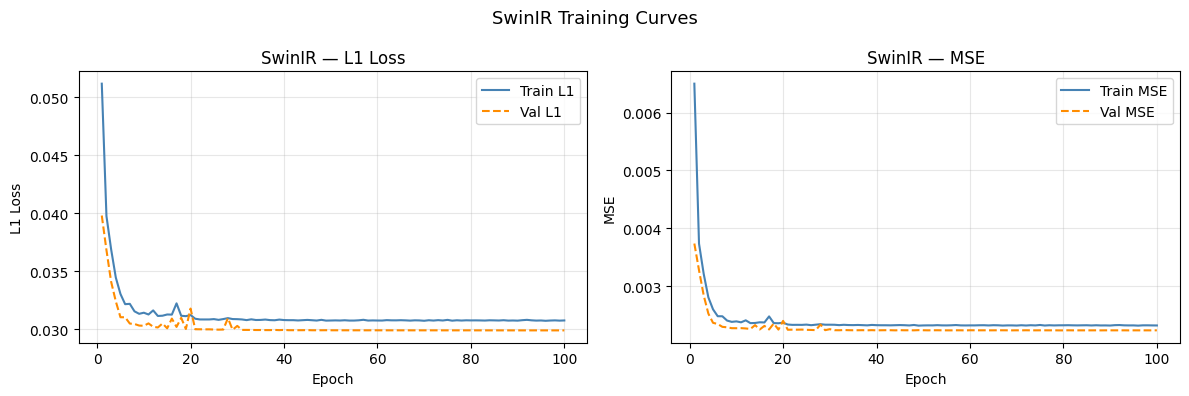

Saved: reports/fig_06_swinir_training_curves.png


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history.history["loss"]) + 1)

ax1.plot(ep, history.history["loss"],     color="steelblue",  label="Train L1")
ax1.plot(ep, history.history["val_loss"], color="darkorange", label="Val L1", linestyle="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("L1 Loss")
ax1.set_title("SwinIR — L1 Loss"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep, history.history["mse"],     color="steelblue",  label="Train MSE")
ax2.plot(ep, history.history["val_mse"], color="darkorange", label="Val MSE", linestyle="--")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("MSE")
ax2.set_title("SwinIR — MSE"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("SwinIR Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "fig_06_swinir_training_curves.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: reports/fig_06_swinir_training_curves.png")

## 7. Test set evaluation

In [17]:
y_true_list, y_pred_list = [], []

for lr_batch, hr_batch in tqdm(test_ds, desc="Evaluating"):
    preds = model(lr_batch, training=False).numpy()
    hrs   = hr_batch.numpy()
    for pred, hr in zip(preds, hrs):
        y_pred_list.append(np.squeeze(pred))
        y_true_list.append(np.squeeze(hr))

swinir_results = evaluate_arrays(y_true_list, y_pred_list)

print_results(bicubic_results, "Bicubic baseline  (test set)")
print_results(swinir_results,  "SwinIR            (test set)")

Evaluating: 100%|██████████| 38/38 [00:09<00:00,  3.91it/s]



Bicubic baseline  (test set)
------------------------------------
  PSNR      : 29.8260 dB
  SSIM      : 0.6090
  ENL pred  : 40.8577
  ENL true  : 10.5417
------------------------------------

SwinIR            (test set)
------------------------------------
  PSNR      : 30.4033 dB
  SSIM      : 0.6652
  ENL pred  : 24.2797
  ENL true  : 10.5417
------------------------------------


## 8. Comparison table — Bicubic vs SRCNN vs SwinIR

Paste the SRCNN results from `05_srcnn.ipynb` into the variables below to produce the full three-way comparison.

In [18]:
# Paste actual SRCNN test set numbers here after running 05_srcnn.ipynb
srcnn_results = {
    "psnr": 30.0066,   # replace with actual value
    "ssim": 0.6552,   # replace with actual value
    "enl_pred": 19.7877,
    "enl_true": swinir_results["enl_true"],
}

print("=" * 64)
print("THREE-WAY COMPARISON (test set)")
print("=" * 64)
print(f"{'Metric':<16} {'Bicubic':>12} {'SRCNN':>12} {'SwinIR':>12}")
print("-" * 64)
for key, label in [("psnr", "PSNR (dB)"), ("ssim", "SSIM"), ("enl_pred", "ENL (pred)")]:
    print(f"{label:<16} {bicubic_results[key]:>12.4f} {srcnn_results[key]:>12.4f} {swinir_results[key]:>12.4f}")
print("=" * 64)

print("\nSwinIR improvement over bicubic:")
print(f"  PSNR  : {swinir_results['psnr'] - bicubic_results['psnr']:+.4f} dB")
print(f"  SSIM  : {swinir_results['ssim'] - bicubic_results['ssim']:+.4f}")

print("\nSpecification check:")
print(f"  Spec 1 (PSNR > bicubic)  : {'PASS' if swinir_results['psnr'] > bicubic_results['psnr'] else 'FAIL'}")
print(f"  Spec 2 (PSNR >= 23 dB)   : {'PASS' if swinir_results['psnr'] >= 23.0 else 'FAIL'}")
print(f"  Spec 3 (SSIM >= 0.70)    : {'PASS' if swinir_results['ssim'] >= 0.70 else 'FAIL'}")

THREE-WAY COMPARISON (test set)
Metric                Bicubic        SRCNN       SwinIR
----------------------------------------------------------------
PSNR (dB)             29.8260      30.0066      30.4033
SSIM                   0.6090       0.6552       0.6652
ENL (pred)            40.8577      19.7877      24.2797

SwinIR improvement over bicubic:
  PSNR  : +0.5773 dB
  SSIM  : +0.0561

Specification check:
  Spec 1 (PSNR > bicubic)  : PASS
  Spec 2 (PSNR >= 23 dB)   : PASS
  Spec 3 (SSIM >= 0.70)    : FAIL


## 9. Sample output grid

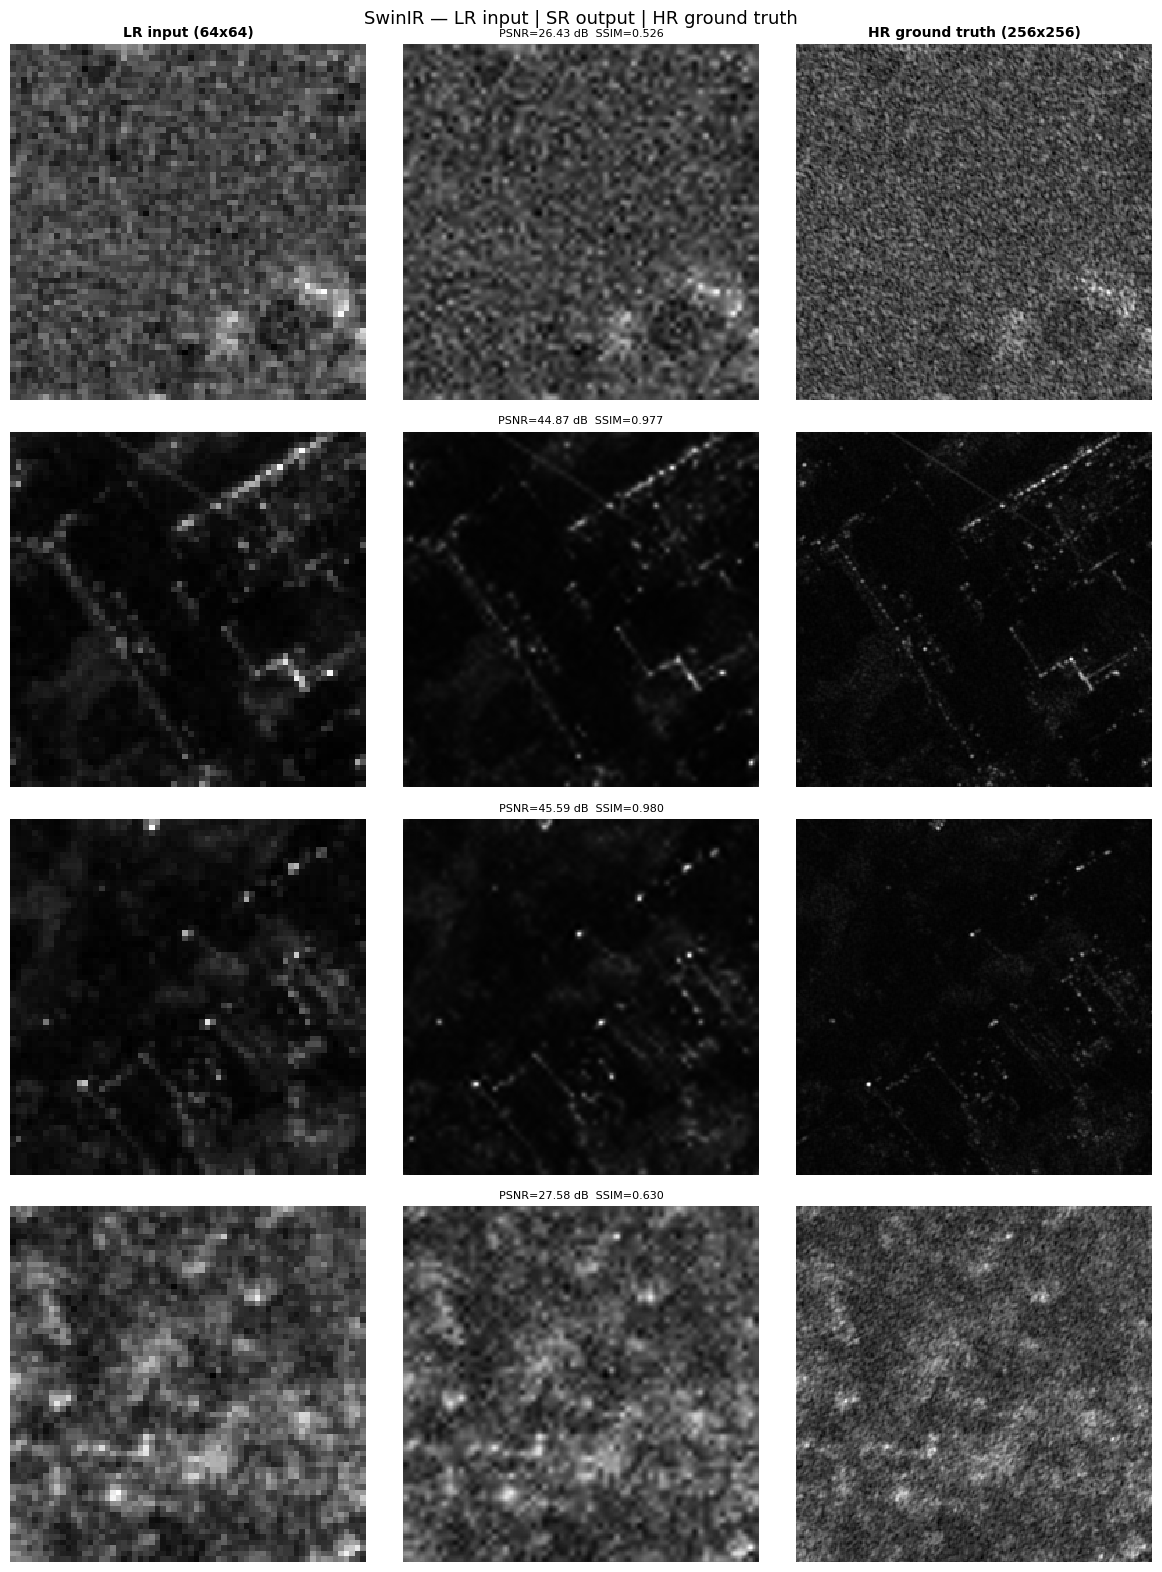

Saved: reports/fig_07_swinir_sample_outputs.png


In [19]:
def log_display(arr):
    arr = np.log1p(arr)
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo) if hi > lo else arr


def center_crop_lr(lr_full, hr_full):
    """Center-crop to LR_SIZE x LR_SIZE (LR) and HR_SIZE x HR_SIZE (HR)."""
    top  = (NATIVE_LR - LR_SIZE) // 2
    left = (NATIVE_LR - LR_SIZE) // 2
    lr_crop = lr_full[top:top+LR_SIZE, left:left+LR_SIZE]
    hr_crop = hr_full[top*SCALE:(top+LR_SIZE)*SCALE, left*SCALE:(left+LR_SIZE)*SCALE]
    return lr_crop, hr_crop


N_SHOW   = 4
show_idx = np.random.default_rng(SEED).choice(len(test_idx), size=N_SHOW, replace=False)

fig, axes = plt.subplots(N_SHOW, 3, figsize=(12, N_SHOW * 4))
fig.suptitle("SwinIR — LR input | SR output | HR ground truth", fontsize=13)

for col, title in enumerate([f"LR input ({LR_SIZE}x{LR_SIZE})",
                              f"SwinIR output ({HR_SIZE}x{HR_SIZE})",
                              f"HR ground truth ({HR_SIZE}x{HR_SIZE})"]):
    axes[0, col].set_title(title, fontsize=10, fontweight="bold")

for row, si in enumerate(show_idx):
    orig_idx = test_idx[si]
    with rasterio.open(all_lr[orig_idx]) as src:
        lr_raw = src.read(1).astype(np.float32)
    with rasterio.open(all_hr[orig_idx]) as src:
        hr_raw = src.read(1).astype(np.float32)

    max_val = hr_raw.max()
    lr_norm = lr_raw / max_val if max_val > 0 else lr_raw
    hr_norm = hr_raw / max_val if max_val > 0 else hr_raw

    # Center-crop to match the eval pipeline — model only accepts LR_SIZE x LR_SIZE
    lr_crop, hr_crop = center_crop_lr(lr_norm, hr_norm)
    lr_crop = np.clip(lr_crop, 0.0, 1.0)

    lr_tensor = tf.constant(lr_crop[np.newaxis, ..., np.newaxis], dtype=tf.float32)
    sr_out = np.squeeze(model(lr_tensor, training=False).numpy())

    axes[row, 0].imshow(log_display(lr_crop), cmap="gray", interpolation="nearest")
    axes[row, 1].imshow(log_display(sr_out),  cmap="gray", interpolation="nearest")
    axes[row, 2].imshow(log_display(hr_crop), cmap="gray", interpolation="nearest")

    psnr_v = psnr(hr_crop, sr_out)
    ssim_v = ssim(hr_crop, sr_out)
    axes[row, 1].set_title(f"PSNR={psnr_v:.2f} dB  SSIM={ssim_v:.3f}", fontsize=8)
    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "fig_07_swinir_sample_outputs.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: reports/fig_07_swinir_sample_outputs.png")